In [1]:
import pandas as pd
import numpy as np
from utils import build_linear_nn_model, plot_loss_function
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import tensorflow as tf

In [2]:
df =pd.read_csv('data/data_1.csv',header=None,names=['feature','target'])
df

,feature,target
0,1651.000000,432.645217
1,1691.816327,454.935530
2,1732.632653,471.525248
3,1773.448980,482.506389
4,1814.265306,468.357886
5,1855.081633,482.152531
6,1895.897959,540.021756
7,1936.714286,534.584267
8,1977.530612,558.346208
9,2018.346939,566.423445


In [3]:
X=np.array(df[['feature']])
Y= np.array(df['target'])

**Splitting the datas into train,test and cross_validation sets**

In [4]:
X_train,X_,Y_train,Y_ = train_test_split(X,Y,test_size=0.40,random_state=1)
X_cv,X_test,Y_cv,Y_test = train_test_split(X_,Y_,test_size=0.50,random_state=1)
del X_,Y_  #deleting the temporary variable
print(f'The number of training data set is: {X_train.shape[0]}')
print(f'The number of cross validation data set is: {X_cv.shape[0]}')
print(f'The number of test data set is: {X_test.shape[0]}')

The number of training data set is: 30
The number of cross validation data set is: 10
The number of test data set is: 10


**As we know in the neural network, the model learns the non_linear relationship by itself inside the algorithm, so no need for polynomial engineering**

**For training data**

In [5]:
pf = PolynomialFeatures(degree=1,include_bias=False)
X_mapped = pf.fit_transform(X_train)
sc = StandardScaler()
X_mapped_scaled = sc.fit_transform(X_mapped)
print(f'The scaled and engineered training data is: {X_mapped_scaled}')

The scaled and engineered training data is: [[ 1.42715997]
 [-0.27691164]
 [ 1.71117191]
 [ 0.22010925]
 [ 0.14910627]
 [-1.19995042]
 [ 0.8591361 ]
 [-0.48992059]
 [ 0.64612715]
 [-0.77393252]
 [ 0.50412118]
 [ 1.64016892]
 [ 0.93013909]
 [-0.20590865]
 [-0.06390269]
 [ 0.29111223]
 [-1.05794446]
 [-0.98694147]
 [ 1.85317788]
 [-1.41295938]
 [-0.34791462]
 [-1.48396236]
 [-0.4189176 ]
 [-1.12894744]
 [-0.70292954]
 [-0.84493551]
 [-0.91593849]
 [-0.63192656]
 [ 1.56916594]
 [ 1.14314804]]


**For cross_validation data**

In [6]:
X_cv_mapped = pf.transform(X_cv)
X_cv_scaled = sc.transform(X_cv_mapped)
print(f'The scaled and engineered cross_validation data is: {X_mapped_scaled}')

The scaled and engineered cross_validation data is: [[ 1.42715997]
 [-0.27691164]
 [ 1.71117191]
 [ 0.22010925]
 [ 0.14910627]
 [-1.19995042]
 [ 0.8591361 ]
 [-0.48992059]
 [ 0.64612715]
 [-0.77393252]
 [ 0.50412118]
 [ 1.64016892]
 [ 0.93013909]
 [-0.20590865]
 [-0.06390269]
 [ 0.29111223]
 [-1.05794446]
 [-0.98694147]
 [ 1.85317788]
 [-1.41295938]
 [-0.34791462]
 [-1.48396236]
 [-0.4189176 ]
 [-1.12894744]
 [-0.70292954]
 [-0.84493551]
 [-0.91593849]
 [-0.63192656]
 [ 1.56916594]
 [ 1.14314804]]


**For test datasets**

In [7]:
X_test_mapped = pf.transform(X_test)
X_test_scaled = sc.transform(X_test_mapped)
print(f'The scaled and engineered test data is: {X_test_scaled}')

The scaled and engineered test data is: [[ 1.21415102]
 [ 1.99518384]
 [ 1.92418086]
 [ 0.78813312]
 [ 1.35615699]
 [-0.13490567]
 [-1.34195639]
 [ 0.36211522]
 [ 0.57512417]
 [ 1.00114207]]


**Evaluation of different neural network model based on the cost function of cross_validation datasets**

Training <Sequential name=model1, built=False>


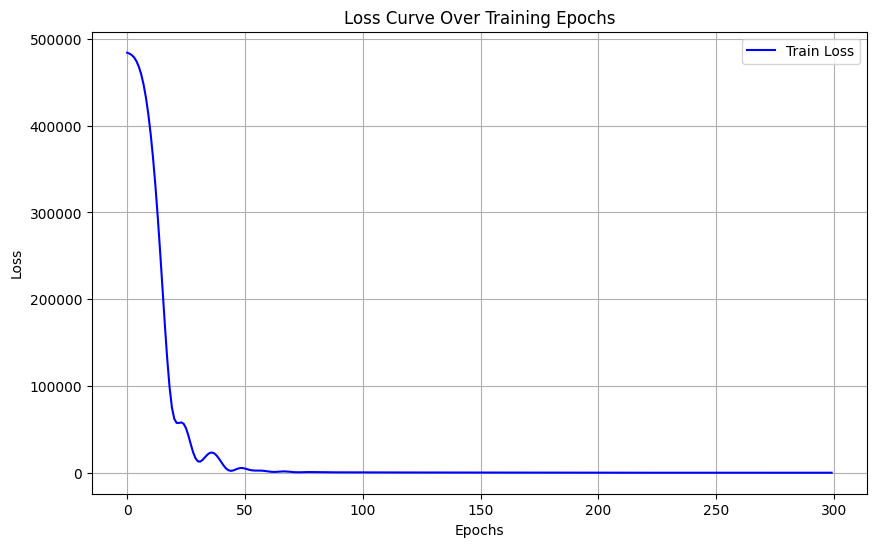

Done

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step
The cost function based on training dataset by <Sequential name=model1, built=True> is: 73.44654461319375
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
The cost function based on cross_validation dataset by <Sequential name=model1, built=True> is: 112.47404297224566
Training <Sequential name=model2, built=False>


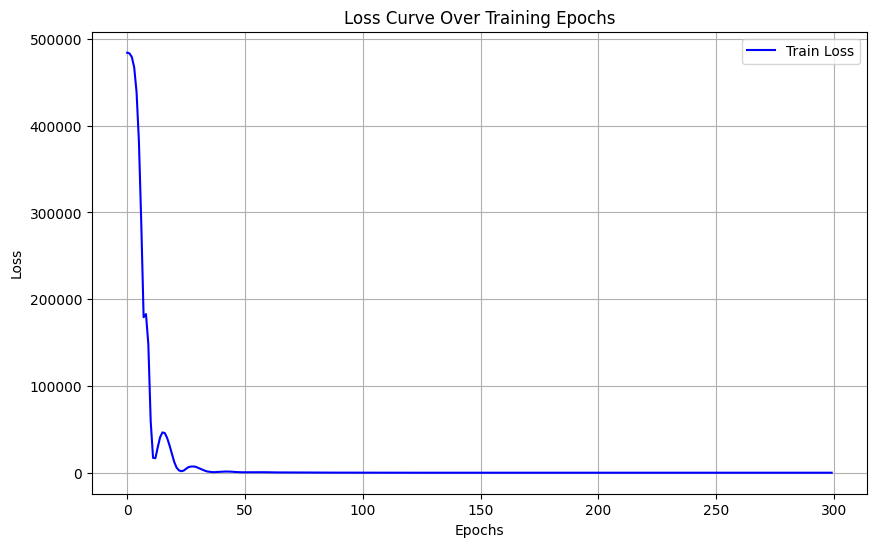

Done

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step
The cost function based on training dataset by <Sequential name=model2, built=True> is: 73.39632433001994
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
The cost function based on cross_validation dataset by <Sequential name=model2, built=True> is: 112.38765603747643
Training <Sequential name=model3, built=False>


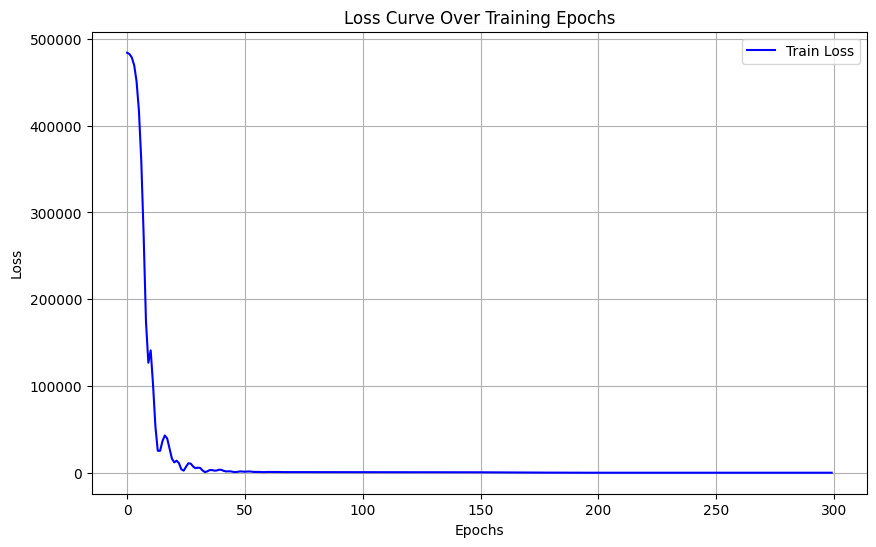

Done

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step
The cost function based on training dataset by <Sequential name=model3, built=True> is: 75.39104560651366
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step
The cost function based on cross_validation dataset by <Sequential name=model3, built=True> is: 98.90793361436543


In [8]:
models = build_linear_nn_model()
nn_train_cf = []  #cost function based on the training dataset
nn_cv_cf = []     #cost function based on the cross_validation dataset
for model in models:
    model.compile(   #loss function for the neural network and optmizing the model
    loss='mse',
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.1),
    )
    print(f'Training {model}')
    history = model.fit(X_mapped_scaled,Y_train,epochs = 300, verbose = 0)  #training the model
    plot_loss_function(history)
    print('Done\n')
    Y_train_prediction = model.predict(X_mapped_scaled)  #predicting the training dataset 
    mse_train = mean_squared_error(Y_train_prediction,Y_train)/2  #calculating the cost function based on training dataset
    nn_train_cf.append(mse_train)
    print(f'The cost function based on training dataset by {model} is: {mse_train}')

    Y_cv_prediction = model.predict(X_cv_scaled)  #predicting the cross_validation dataset
    mse_cv = mean_squared_error(Y_cv_prediction,Y_cv)/2  #cost function based on cross_validation dataset
    nn_cv_cf.append(mse_cv)
    print(f'The cost function based on cross_validation dataset by {model} is: {mse_cv}')


In [9]:
print(f'The cost function based on training dataset, obtained from provided neural networks are: {nn_train_cf}')
print(f'The cost function based on cross_validation dataset, obtained from provided neural networks are: {nn_cv_cf}')

The cost function based on training dataset, obtained from provided neural networks are: [73.44654461319375, 73.39632433001994, 75.39104560651366]
The cost function based on cross_validation dataset, obtained from provided neural networks are: [112.47404297224566, 112.38765603747643, 98.90793361436543]


**Finding the best model based on the most minimum cost function of the cross_validation dataset**

In [10]:
req_index= np.argmin(nn_cv_cf)   #here we are choosing the index where the cost function is the minimum
best_model=models[req_index]
print(f'The best model is {best_model}')

The best model is <Sequential name=model3, built=True>


**Finding the cost function of the test dataset**

In [11]:
Y_test_prediction = best_model.predict(X_test_scaled)
mse_test = mean_squared_error(Y_test_prediction,Y_test)/2
print(f'The cost function of the test dataset is: {mse_test}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
The cost function of the test dataset is: 112.22305178436822


**As we can see, the cost function of the test dataset provided by the chosen nn model is 112.223 which is the most minimum compared to the cost function, provided by other neural network models.**